# FIN7053 - Algorithmic Trading - Final Project
## Momentum-Driven Capital Preservation Portfolio
### Benjamin Tallman

In [1]:
# Library Load

!pip install alpaca-py -q

import numpy as np
import pandas as pd
import cvxpy as cp
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.data.enums import DataFeed

API_KEY    = "Your key here"
API_SECRET = "Your private key here"

trading_client = TradingClient(API_KEY, API_SECRET, paper=True)
data_client    = StockHistoricalDataClient(API_KEY, API_SECRET)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 3.4 MB/s eta 0:00:00


In [2]:
# Initial Universe of Stocks

UNIVERSE = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL",
    "META", "TSLA", "BRK.B", "LLY", "AVGO",
    "JPM",  "UNH",  "V",    "XOM", "MA",
    "COST", "HD",   "PG",   "JNJ", "ABBV"
]

PORTFOLIO_SIZE   = 10
MOM_LOOKBACK   = 80
MOM_SKIP       = 10
PRICE_LOOKBACK = 145
DRIFT_THRESHOLD  = 0.02
REBALANCE_DAYS   = 14
VIX_THRESHOLD  = 23
VIX_REENTRY    = 18
SAFE_HAVEN       = "BIL"

print(f"Universe        : {len(UNIVERSE)} stocks")
print(f"Portfolio size  : {PORTFOLIO_SIZE} stocks (top by momentum)")
print(f"Momentum        : {MOM_LOOKBACK}-day lookback, {MOM_SKIP}-day skip")
print(f"Rebalance       : every {REBALANCE_DAYS} days")
print(f"VIX trigger     : {VIX_THRESHOLD} | Re-entry: {VIX_REENTRY}")
print(f"Safe haven      : {SAFE_HAVEN}")

Universe        : 20 stocks
Portfolio size  : 10 stocks (top by momentum)
Momentum        : 80-day lookback, 10-day skip
Rebalance       : every 14 days
VIX trigger     : 23 | Re-entry: 18
Safe haven      : BIL


In [3]:
# Data Parameters Set-up

def get_bars(tickers: list, days: int = PRICE_LOOKBACK) -> pd.DataFrame:
    request_params = StockBarsRequest(
        symbol_or_symbols=tickers,
        timeframe=TimeFrame.Day,
        start=datetime.now() - timedelta(days=days + 10),
        end=datetime.now(),
        feed=DataFeed.IEX
    )
    bars       = data_client.get_stock_bars(request_params)
    close_data = {}
    for ticker in tickers:
        try:
            ticker_bars        = bars[ticker]
            close_data[ticker] = {b.timestamp: b.close for b in ticker_bars}
        except Exception:
            pass
    df       = pd.DataFrame(close_data)
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df.sort_index()


def calculate_momentum(prices_df: pd.DataFrame,
                       lookback: int = MOM_LOOKBACK,
                       skip: int = MOM_SKIP) -> pd.Series:

    if len(prices_df) < lookback + skip:
           return pd.Series(dtype=float)

    price_start = prices_df.iloc[-(lookback + skip)]
    price_end   = prices_df.iloc[-skip]
    momentum    = (price_end / price_start - 1).dropna()
    return momentum.sort_values(ascending=False)


def screen_momentum(prices_df: pd.DataFrame,
                    top_n: int = PORTFOLIO_SIZE) -> pd.DataFrame:

    print("\nMomentum Screen...")
    momentum = calculate_momentum(prices_df[UNIVERSE])

    if momentum.empty:
        return pd.DataFrame()

    df           = momentum.head(top_n).reset_index()
    df.columns   = ["ticker", "momentum"]
    df["momentum"] = df["momentum"].round(4)

    print(f"Top {len(df)} momentum stocks:")
    print(df.to_string(index=False))
    return df


def optimize_weights(screened_df: pd.DataFrame,
                     prices_df: pd.DataFrame) -> dict:

    tickers   = screened_df["ticker"].tolist()
    available = [t for t in tickers if t in prices_df.columns]
    n         = len(available)

    if n < 2:
        return {t: 1.0 / n for t in available}

    returns    = prices_df[available].pct_change().dropna().tail(MOM_LOOKBACK)
    cov_matrix = returns.cov().values * 252

    w           = cp.Variable(n)
    objective   = cp.Minimize(cp.quad_form(w, cov_matrix))
    constraints = [cp.sum(w) == 1, w >= 0.02, w <= 0.25]
    problem     = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.OSQP, warm_start=True)
    except Exception as e:
        print(f"  Solver error: {e}")
        return {t: 1.0 / n for t in available}

    if problem.status not in ["optimal", "optimal_inaccurate"] or w.value is None:
        return {t: 1.0 / n for t in available}

    raw  = np.clip(w.value, 0, 1)
    raw /= raw.sum()
    weights = {t: round(float(wt), 6) for t, wt in zip(available, raw)}

    print(f"\n  Optimizer status : {problem.status}")
    print(f"  Portfolio vol    : {np.sqrt(problem.value)*100:.2f}% annualized")
    print(f"  {'Ticker':<8} {'Weight':>8}  {'Momentum':>10}")
    print(f"  {'-'*30}")
    for t, wt in sorted(weights.items(), key=lambda x: -x[1]):
        mom = screened_df[screened_df["ticker"]==t]["momentum"].values
        m   = mom[0] if len(mom) > 0 else 0
        print(f"  {t:<8} {wt:>7.2%}  {m:>9.2%}")
    return weights


def check_vix_circuit_breaker(threshold: float = VIX_THRESHOLD) -> dict:
    try:
        hist      = yf.Ticker("^VIX").history(period="5d")
        vix_price = round(float(hist["Close"].iloc[-1]), 2)
        bar_date  = hist.index[-1].date()
        triggered = vix_price >= threshold
        status    = "TRIGGERED" if triggered else "CLEAR"
        marker    = "TRIGGERED" if triggered else "CLEAR"

        print(f"\nVIX Circuit Breaker")
        print(f"  {marker} {status}")
        print(f"  VIX    : {vix_price:.2f}")
        print(f"  Trigger: {threshold:.2f}")
        print(f"  Date   : {bar_date}")

        return {"triggered": triggered, "vix_price": vix_price,
                "threshold": threshold, "bar_date": bar_date,
                "status": status}
    except Exception as e:
        return {"triggered": False, "vix_price": None,
                "threshold": threshold, "status": f"ERROR: {e}"}


# --- Test ---
print("Testing Data")
test_prices = get_bars(UNIVERSE + ["BIL"])
print(f"Price matrix: {test_prices.shape}")
print(f"Date range  : {test_prices.index[0].date()} → "
      f"{test_prices.index[-1].date()}")

Testing Data
Price matrix: (105, 21)
Date range  : 2025-11-18 → 2026-04-21


In [4]:
# Current Portfolio Screen and Optimization

prices_df = get_bars(UNIVERSE + ["BIL"])

screened_portfolio = screen_momentum(prices_df)

print("\nOptimized Portfolio Weights...")
optimized_weights = optimize_weights(screened_portfolio, prices_df)


Momentum Screen...
Top 10 momentum stocks:
ticker  momentum
   XOM    0.3070
  COST    0.1782
   JNJ    0.1684
    PG    0.0366
   JPM   -0.0069
  NVDA   -0.0089
 GOOGL   -0.0093
 BRK.B   -0.0220
   LLY   -0.0401
    HD   -0.0424

Optimized Portfolio Weights...

  Optimizer status : optimal
  Portfolio vol    : 8.56% annualized
  Ticker     Weight    Momentum
  ------------------------------
  BRK.B     25.00%     -2.20%
  JNJ       22.71%     16.84%
  XOM       14.63%     30.70%
  COST      11.40%     17.82%
  NVDA       7.98%     -0.89%
  GOOGL      6.97%     -0.93%
  JPM        5.30%     -0.69%
  PG         2.00%      3.66%
  LLY        2.00%     -4.01%
  HD         2.00%     -4.24%


In [5]:
# Alpaca Execution

def get_portfolio_equity() -> float:
    return float(trading_client.get_account().equity)


def get_current_positions() -> dict:
    return {p.symbol: {"qty": float(p.qty),
                       "market_value": float(p.market_value)}
            for p in trading_client.get_all_positions()}


def get_live_prices(tickers: list) -> dict:
    try:
        bars   = data_client.get_stock_bars(StockBarsRequest(
            symbol_or_symbols=tickers,
            timeframe=TimeFrame.Day,
            start=datetime.now() - timedelta(days=5),
            end=datetime.now(),
            feed=DataFeed.IEX
        ))
        return {t: bars[t][-1].close for t in tickers if bars[t]}
    except Exception as e:
        print(f"Price fetch error: {e}")
        return {}


def place_order(ticker: str, qty: int, side: OrderSide) -> bool:
    if qty <= 0:
        return False
    try:
        trading_client.submit_order(MarketOrderRequest(
            symbol=ticker, qty=qty,
            side=side, time_in_force=TimeInForce.DAY
        ))
        print(f"  {'BUY' if side == OrderSide.BUY else 'SELL'} "
              f"{qty} {ticker}")
        return True
    except Exception as e:
        print(f"  {ticker}: {e}")
        return False


def calculate_target_shares(target_weights: dict,
                             equity: float) -> dict:
    tickers = list(target_weights.keys())
    prices  = get_live_prices(tickers)
    result  = {}
    for ticker, weight in target_weights.items():
        try:
            price = prices[ticker]
            result[ticker] = {
                "shares":        int(equity * weight / price),
                "price":         price,
                "dollar_target": equity * weight
            }
        except Exception:
            result[ticker] = {
                "shares": 0, "price": None, "dollar_target": 0
            }
    return result


def rebalance_portfolio(target_weights: dict) -> None:
    equity  = get_portfolio_equity()
    current = get_current_positions()
    targets = calculate_target_shares(target_weights, equity)

    print(f"\nRebalancing | Equity: ${equity:,.2f} | "
          f"Positions: {len(targets)}")
    print(f"{'Ticker':<8} {'Target $':>12} {'Current $':>12} "
          f"{'Drift':>8}  Action")
    print("-" * 60)

    for side_filter in ["sell", "buy"]:
        for ticker, data in targets.items():
            cur_val = current.get(ticker, {}).get("market_value", 0)
            tgt_val = data["dollar_target"]
            drift   = abs(tgt_val - cur_val) / equity if equity > 0 else 0
            cur_qty = int(current.get(ticker, {}).get("qty", 0))
            tgt_qty = data["shares"]
            delta   = tgt_qty - cur_qty

            if drift < DRIFT_THRESHOLD:
                if side_filter == "sell":
                    print(f"  {ticker:<6} ${tgt_val:>10,.0f}  "
                          f"${cur_val:>10,.0f}  {drift:>6.1%}   HOLD")
                continue
            if side_filter == "sell" and delta < 0:
                place_order(ticker, abs(delta), OrderSide.SELL)
            elif side_filter == "buy" and delta > 0:
                place_order(ticker, delta, OrderSide.BUY)
        if side_filter == "sell":
            time.sleep(1)
    print("Rebalanced")


def liquidate_to_safe_haven() -> None:
    print(f"\n Liquidating → {SAFE_HAVEN}")
    current = get_current_positions()
    for ticker, data in current.items():
        if ticker == SAFE_HAVEN:
            continue
        qty = int(data["qty"])
        if qty > 0:
            place_order(ticker, qty, OrderSide.SELL)
        elif qty < 0:
            place_order(ticker, abs(qty), OrderSide.BUY)
    time.sleep(3)
    prices     = get_live_prices([SAFE_HAVEN])
    bil_price  = prices.get(SAFE_HAVEN, 91.0)
    equity     = get_portfolio_equity()
    bil_shares = int(equity / bil_price)
    place_order(SAFE_HAVEN, bil_shares, OrderSide.BUY)
    print(f"  {bil_shares} shares {SAFE_HAVEN} @ ${bil_price:.2f}")


def flatten_all_positions() -> None:
    current = get_current_positions()
    if not current:
        print("Already flat.")
        return
    for ticker, data in current.items():
        qty = data["qty"]
        if qty > 0:
            place_order(ticker, int(qty), OrderSide.SELL)
        elif qty < 0:
            place_order(ticker, int(abs(qty)), OrderSide.BUY)
    time.sleep(3)
    print(f"Flat. Equity: ${get_portfolio_equity():,.2f}")


# --- Confirm ---
print(f"Equity    : ${get_portfolio_equity():,.2f}")
print(f"Positions : {get_current_positions()}")

Equity    : $110,699.25
Positions : {'BRK.B': {'qty': 58.0, 'market_value': 27270.44}, 'COST': {'qty': 10.0, 'market_value': 10049.6}, 'GOOGL': {'qty': 24.0, 'market_value': 8050.8}, 'JNJ': {'qty': 119.0, 'market_value': 27524.7}, 'JPM': {'qty': 20.0, 'market_value': 6316.8}, 'LLY': {'qty': 2.0, 'market_value': 1823.0}, 'NVDA': {'qty': 38.0, 'market_value': 7636.48}, 'PG': {'qty': 15.0, 'market_value': 2146.95}, 'UNH': {'qty': 6.0, 'market_value': 2064.12}, 'XOM': {'qty': 106.0, 'market_value': 15656.2}}


In [6]:
# VIX Run Test
def daily_run() -> None:

    print(f"\n{'='*55}")
    print(f"DAILY RUN — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*55}")

    cb      = check_vix_circuit_breaker()
    current = get_current_positions()
    in_safe = (len(current) == 1 and SAFE_HAVEN in current) or len(current) == 0

    if cb["triggered"]:
        if SAFE_HAVEN in current and len(current) == 1:
            print(f"\n Already in {SAFE_HAVEN}.")
        else:
            liquidate_to_safe_haven()
    else:
        if in_safe:
            print(f"\n VIX clear. Rebuilding momentum portfolio...")
            prices_df = get_bars(UNIVERSE + [SAFE_HAVEN])
            screened  = screen_momentum(prices_df)
            if not screened.empty:
                weights = optimize_weights(screened, prices_df)
                if SAFE_HAVEN in current:
                    qty = int(current[SAFE_HAVEN]["qty"])
                    place_order(SAFE_HAVEN, qty, OrderSide.SELL)
                    time.sleep(2)
                rebalance_portfolio(weights)
        else:
            print(f"\n VIX clear at {cb['vix_price']:.2f}. "
                  f"Portfolio invested. Holding.")


def weekly_run() -> None:

    print(f"\n{'='*55}")
    print(f"WEEKLY RUN — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*55}")

    cb = check_vix_circuit_breaker()
    if cb["triggered"]:
        print(f"\n  VIX {cb['vix_price']:.2f} >= {VIX_THRESHOLD}. "
              f"Staying in {SAFE_HAVEN}.")
        return

    print(f"\n VIX clear. Running momentum rescreen...")
    prices_df = get_bars(UNIVERSE + [SAFE_HAVEN])
    screened  = screen_momentum(prices_df)

    if screened.empty:
        print("WARNING: Empty screen. Holding current positions.")
        return

    weights = optimize_weights(screened, prices_df)
    current = get_current_positions()

    for ticker in list(current.keys()):
        if ticker not in weights and ticker != SAFE_HAVEN:
            print(f"  Exiting {ticker} — not in new portfolio")
            place_order(ticker, int(current[ticker]["qty"]), OrderSide.SELL)

    time.sleep(2)
    rebalance_portfolio(weights)


# --- Test daily run ---
daily_run()


DAILY RUN — 2026-04-22 03:24:21

VIX Circuit Breaker
  CLEAR CLEAR
  VIX    : 19.50
  Trigger: 23.00
  Date   : 2026-04-21

 VIX clear at 19.50. Portfolio invested. Holding.


In [7]:
# Backtest
BT_START          = "2021-01-01"
BT_END            = datetime.now().strftime("%Y-%m-%d")
BT_INITIAL_EQUITY = 1_000_000
BT_COMMISSION     = 0.0005
BT_REBAL_DAYS     = 14
BT_MOM_LOOKBACK   = 252
BT_MOM_SKIP       = 21
BT_VIX_TRIGGER = 23.0
BT_VIX_REENTRY = 18.0
BT_PORTFOLIO_SIZE = 10

print("5-year history via Alpaca IEX...")
bt_tickers = UNIVERSE + ["BIL", "SPY"]

bt_request = StockBarsRequest(
    symbol_or_symbols=bt_tickers,
    timeframe=TimeFrame.Day,
    start=datetime(2021, 1, 1),
    end=datetime.now(),
    feed=DataFeed.IEX
)
bt_bars = data_client.get_stock_bars(bt_request)

bt_close = {}
for ticker in bt_tickers:
    try:
        bars = bt_bars[ticker]
        bt_close[ticker] = {b.timestamp: b.close for b in bars}
        print(f" {ticker}: {len(bars)} bars")
    except Exception:
        print(f" {ticker}: no data")

bt_prices       = pd.DataFrame(bt_close)
bt_prices.index = pd.to_datetime(bt_prices.index).tz_localize(None)
bt_prices       = bt_prices.sort_index()

# Alpaca did not have VIX, so I used yFinance.  Alpaca was still used the for the execution.
vix_raw    = yf.download("^VIX", start=BT_START, end=BT_END,
                          auto_adjust=True, progress=False)
vix_series = vix_raw["Close"].squeeze()
vix_series.index = pd.to_datetime(vix_series.index).tz_localize(None)

print(f"\nPrice matrix : {bt_prices.shape[0]} days × "
      f"{bt_prices.shape[1]} tickers")
print(f"Date range   : {bt_prices.index[0].date()} → "
      f"{bt_prices.index[-1].date()}")
print(f"VIX range    : {vix_series.min():.1f} – {vix_series.max():.1f}")

def get_vix_on_date(date):
    past = vix_series[vix_series.index <= date]
    return float(past.iloc[-1]) if len(past) > 0 else 15.0

def bt_screen_and_optimize(date, prices_df):
    window    = prices_df.loc[:date]
    available = [t for t in UNIVERSE if t in window.columns]

    if len(window) < BT_MOM_LOOKBACK + BT_MOM_SKIP + 5:
        return {}

    price_start = window.iloc[-(BT_MOM_LOOKBACK + BT_MOM_SKIP)]
    price_end   = window.iloc[-BT_MOM_SKIP]
    momentum    = (price_end[available] /
                   price_start[available] - 1).dropna()
    momentum    = momentum.sort_values(ascending=False)

    if momentum.empty:
        return {}

    tickers    = momentum.head(BT_PORTFOLIO_SIZE).index.tolist()
    returns_df = window[tickers].pct_change().dropna().tail(
        BT_MOM_LOOKBACK
    )

    if len(returns_df) < 60:
        return {t: 1.0 / len(tickers) for t in tickers}

    cov_matrix  = returns_df.cov().values * 252
    n           = len(tickers)
    w           = cp.Variable(n)
    objective   = cp.Minimize(cp.quad_form(w, cov_matrix))
    constraints = [cp.sum(w) == 1, w >= 0.02, w <= 0.25]
    problem     = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.OSQP, warm_start=True)
    except Exception:
        return {t: 1.0 / n for t in tickers}

    if problem.status not in ["optimal", "optimal_inaccurate"] \
            or w.value is None:
        return {t: 1.0 / n for t in tickers}

    raw  = np.clip(w.value, 0, 1)
    raw /= raw.sum()
    return {t: float(wt) for t, wt in zip(tickers, raw)}


def compute_tc(old_weights, new_weights, equity):
    all_tickers = set(old_weights) | set(new_weights)
    drift       = sum(abs(new_weights.get(t, 0) - old_weights.get(t, 0))
                      for t in all_tickers)
    return equity * drift * BT_COMMISSION

print("\nWalk-forward backtest")

all_dates       = bt_prices.index.tolist()
rebal_dates     = all_dates[BT_MOM_LOOKBACK + BT_MOM_SKIP::BT_REBAL_DAYS]

equity          = BT_INITIAL_EQUITY
spy_equity      = BT_INITIAL_EQUITY
current_weights = {}
in_safe_haven   = False
equity_curve    = []
dates_curve     = []
rebal_log       = []

for i, rebal_date in enumerate(rebal_dates):
    vix = get_vix_on_date(rebal_date)

    if vix >= BT_VIX_TRIGGER:
        new_weights   = {"BIL": 1.0}
        in_safe_haven = True
    elif in_safe_haven and vix > BT_VIX_REENTRY:
        new_weights   = current_weights
    else:
        in_safe_haven = False
        new_weights   = bt_screen_and_optimize(rebal_date, bt_prices)
        if not new_weights:
            new_weights = current_weights if current_weights \
                else {"BIL": 1.0}

    tc     = compute_tc(current_weights, new_weights, equity)
    equity -= tc

    next_date     = rebal_dates[i+1] if i+1 < len(rebal_dates) \
        else all_dates[-1]
    period_return = 0.0

    for ticker, weight in new_weights.items():
        if ticker not in bt_prices.columns:
            continue
        p_start = bt_prices.loc[rebal_date, ticker]
        p_end   = bt_prices.loc[next_date, ticker]
        if pd.isna(p_start) or pd.isna(p_end) or p_start == 0:
            continue
        period_return += weight * (p_end / p_start - 1)

    equity *= (1 + period_return)

    spy_start = bt_prices.loc[rebal_date, "SPY"]
    spy_end   = bt_prices.loc[next_date, "SPY"]
    if not pd.isna(spy_start) and not pd.isna(spy_end) \
            and spy_start > 0:
        spy_equity *= (spy_end / spy_start)

    equity_curve.append(equity)
    dates_curve.append(rebal_date)
    current_weights = new_weights

    rebal_log.append({
        "date":          rebal_date,
        "vix":           round(vix, 2),
        "safe_haven":    in_safe_haven,
        "n_holdings":    len(new_weights),
        "period_return": round(period_return * 100, 3),
        "equity":        round(equity, 2),
        "tc":            round(tc, 2)
    })

    if i % 10 == 0:
        status = "BIL" if in_safe_haven else f"{len(new_weights)} stocks"
        print(f"  {rebal_date.date()}  VIX={vix:5.1f}  {status:<15}  "
              f"Return={period_return*100:+.2f}%  "
              f"Equity=${equity:,.0f}")

print(f"\nFinal equity : ${equity:,.2f}")
print(f"SPY benchmark: ${spy_equity:,.2f}")

5-year history via Alpaca IEX...
 AAPL: 1330 bars
 MSFT: 1330 bars
 NVDA: 1330 bars
 AMZN: 1330 bars
 GOOGL: 1330 bars
 META: 1330 bars
 TSLA: 1330 bars
 BRK.B: 1327 bars
 LLY: 1327 bars
 AVGO: 1330 bars
 JPM: 1327 bars
 UNH: 1327 bars
 V: 1327 bars
 XOM: 1327 bars
 MA: 1327 bars
 COST: 1330 bars
 HD: 1327 bars
 PG: 1327 bars
 JNJ: 1327 bars
 ABBV: 1328 bars
 BIL: 1319 bars
 SPY: 1330 bars

Price matrix : 1330 days × 22 tickers
Date range   : 2021-01-04 → 2026-04-21
VIX range    : 11.9 – 52.3

Walk-forward backtest
  2022-02-02  VIX= 22.1  1 stocks         Return=-0.01%  Equity=$999,445
  2022-08-24  VIX= 22.8  BIL              Return=-0.03%  Equity=$1,000,101
  2023-03-16  VIX= 23.0  BIL              Return=-0.17%  Equity=$1,000,703
  2023-10-05  VIX= 18.5  10 stocks        Return=+1.45%  Equity=$1,119,460
  2024-04-26  VIX= 15.0  10 stocks        Return=+5.11%  Equity=$1,409,982
  2024-11-14  VIX= 14.3  10 stocks        Return=+3.33%  Equity=$1,444,875
  2025-06-10  VIX= 17.0  10 sto

         BACKTEST PERFORMANCE SUMMARY
Metric                        Strategy          SPY
-------------------------------------------------------
Final Equity              $1,463,526.13 $1,539,644.35
Total Return                    46.35%       53.96%
CAGR                             9.52%       10.85%
Sharpe Ratio                    0.8671       0.6458
Sortino Ratio                   1.1203       1.0065
Max Drawdown                   -11.89%      -17.32%
VIX Triggers                        30
Total Tx Costs            $  23,628.15
Backtest Period                  4.19 yrs

Circuit breaker triggered 30 times:
  2022-02-23  VIX=31.0
  2022-03-15  VIX=29.8
  2022-04-04  VIX=18.6
  2022-04-25  VIX=27.0
  2022-05-13  VIX=28.9
  2022-06-03  VIX=24.8
  2022-06-24  VIX=27.2
  2022-07-15  VIX=24.2
  2022-08-04  VIX=21.4
  2022-08-24  VIX=22.8


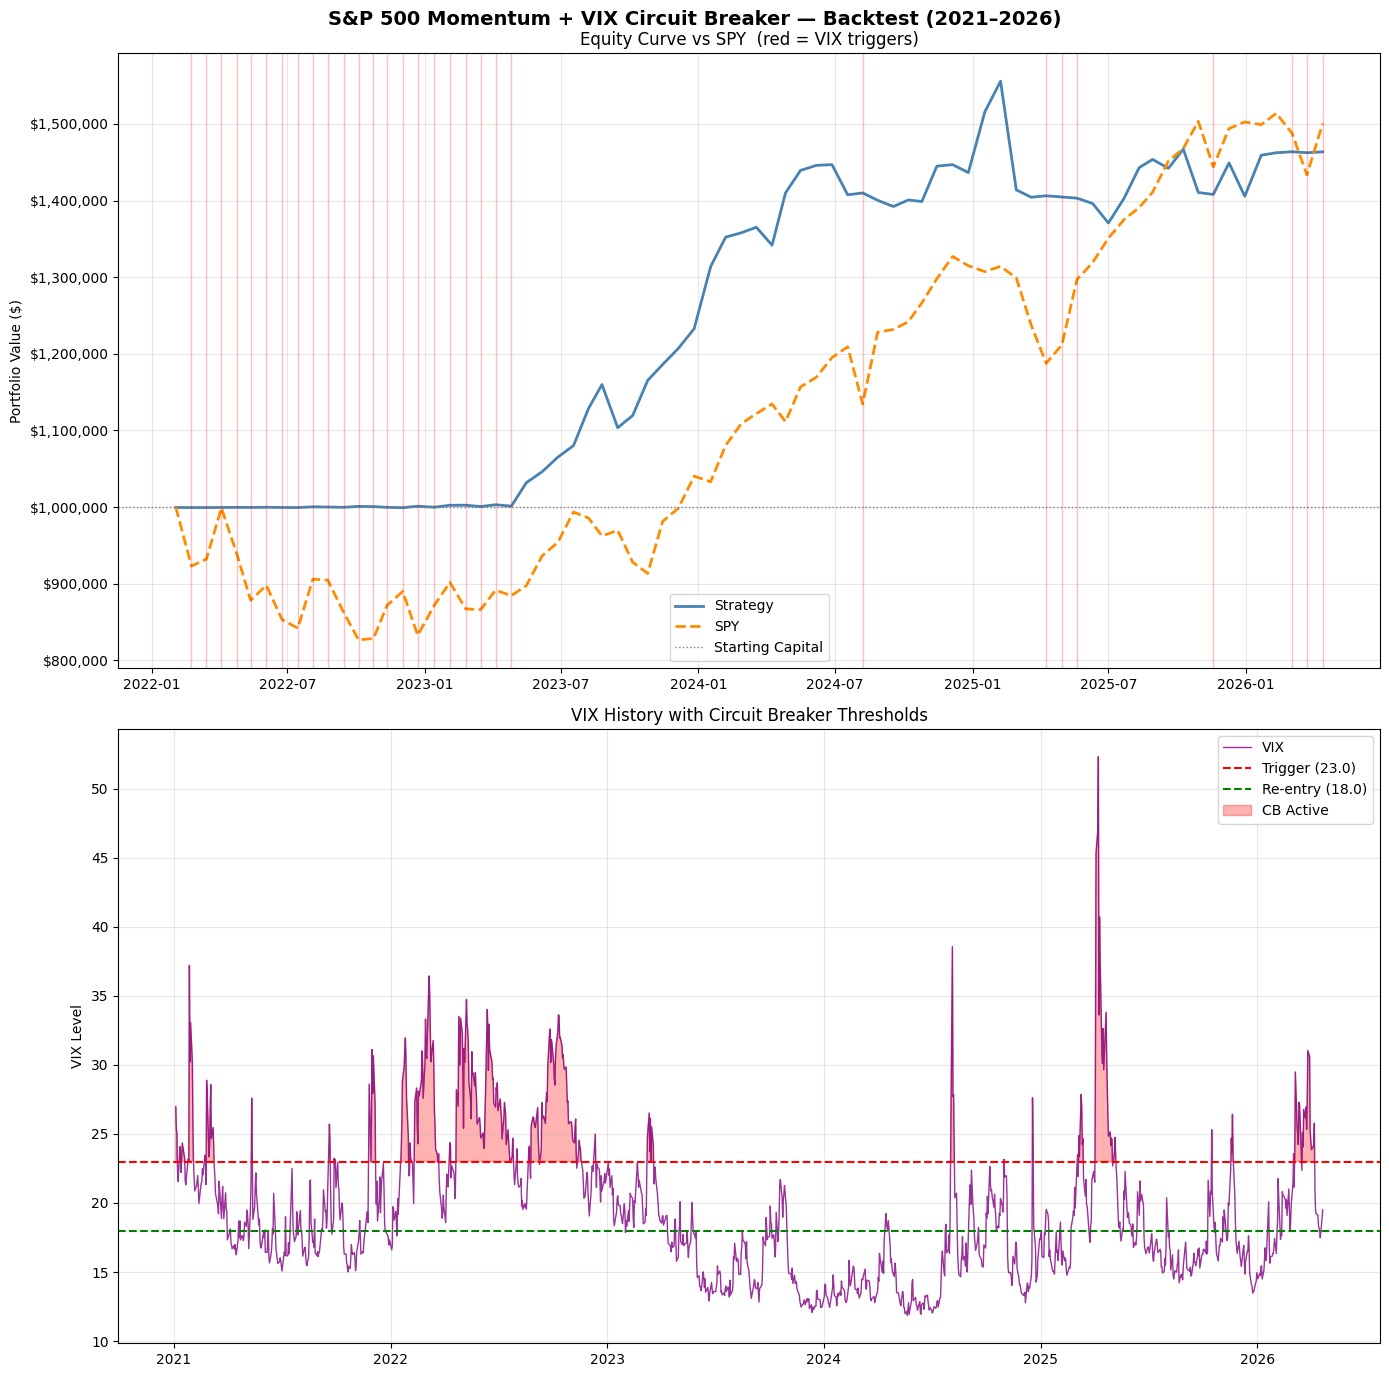

In [8]:
# Portfolio Performance
equity_series  = pd.Series(equity_curve, index=dates_curve)
returns_series = equity_series.pct_change().dropna()

def max_drawdown(eq):
    dd = (eq - eq.cummax()) / eq.cummax()
    return dd.min()

def sharpe_ratio(ret, rf=0.04, periods=26):
    excess = ret - rf / periods
    return (excess.mean() / excess.std()) * np.sqrt(periods) \
        if excess.std() > 0 else 0

def sortino_ratio(ret, rf=0.04, periods=26):
    excess   = ret - rf / periods
    downside = excess[excess < 0].std()
    return (excess.mean() / downside) * np.sqrt(periods) \
        if downside > 0 else 0

def cagr(start, end, years):
    return (end / start) ** (1 / years) - 1

spy_prices_bt = bt_prices["SPY"].reindex(dates_curve).ffill()
spy_series    = spy_prices_bt / spy_prices_bt.iloc[0] * BT_INITIAL_EQUITY
spy_returns   = spy_series.pct_change().dropna()
years         = (dates_curve[-1] - dates_curve[0]).days / 365.25

strat_cagr    = cagr(BT_INITIAL_EQUITY, equity, years)
spy_cagr      = cagr(BT_INITIAL_EQUITY, spy_equity, years)
strat_sharpe  = sharpe_ratio(returns_series)
spy_sharpe    = sharpe_ratio(spy_returns)
strat_sortino = sortino_ratio(returns_series)
spy_sortino   = sortino_ratio(spy_returns)
strat_mdd     = max_drawdown(equity_series)
spy_mdd       = max_drawdown(spy_series)
total_tc      = sum(r["tc"] for r in rebal_log)
n_triggers    = sum(1 for r in rebal_log if r["safe_haven"])

print("=" * 55)
print("         BACKTEST PERFORMANCE SUMMARY")
print("=" * 55)
print(f"{'Metric':<25} {'Strategy':>12} {'SPY':>12}")
print("-" * 55)
print(f"{'Final Equity':<25} ${equity:>11,.2f} ${spy_equity:>11,.2f}")
print(f"{'Total Return':<25} "
      f"{(equity/BT_INITIAL_EQUITY-1)*100:>11.2f}% "
      f"{(spy_equity/BT_INITIAL_EQUITY-1)*100:>11.2f}%")
print(f"{'CAGR':<25} {strat_cagr*100:>11.2f}% {spy_cagr*100:>11.2f}%")
print(f"{'Sharpe Ratio':<25} {strat_sharpe:>12.4f} {spy_sharpe:>12.4f}")
print(f"{'Sortino Ratio':<25} {strat_sortino:>12.4f} {spy_sortino:>12.4f}")
print(f"{'Max Drawdown':<25} {strat_mdd*100:>11.2f}% {spy_mdd*100:>11.2f}%")
print(f"{'VIX Triggers':<25} {n_triggers:>12}")
print(f"{'Total Tx Costs':<25} ${total_tc:>11,.2f}")
print(f"{'Backtest Period':<25} {years:>11.2f} yrs")
print("=" * 55)

# Circuit breaker dates
rebal_df  = pd.DataFrame(rebal_log)
cb_dates  = rebal_df[rebal_df["safe_haven"]==True]["date"].tolist()
print(f"\nCircuit breaker triggered {len(cb_dates)} times:")
for d in cb_dates[:10]:
    v = rebal_df[rebal_df["date"]==d]["vix"].values[0]
    print(f"  {d.date()}  VIX={v:.1f}")

# Charts
fig, axes = plt.subplots(2, 1, figsize=(14, 14))
fig.suptitle(
    "S&P 500 Momentum + VIX Circuit Breaker — Backtest (2021–2026)",
    fontsize=14, fontweight="bold"
)

ax1 = axes[0]
ax1.plot(dates_curve, equity_curve, label="Strategy",
         color="steelblue", linewidth=2)
ax1.plot(dates_curve, spy_series.values, label="SPY",
         color="darkorange", linewidth=2, linestyle="--")
ax1.axhline(BT_INITIAL_EQUITY, color="gray", linestyle=":",
            linewidth=1, label="Starting Capital")
for d in cb_dates:
    ax1.axvline(d, color="red", alpha=0.25, linewidth=1)
ax1.set_title("Equity Curve vs SPY  (red = VIX triggers)")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax2 = axes[1]
ax2.plot(vix_series.index, vix_series.values,
         color="purple", linewidth=1, alpha=0.8, label="VIX")
ax2.axhline(BT_VIX_TRIGGER, color="red", linestyle="--",
            linewidth=1.5, label=f"Trigger ({BT_VIX_TRIGGER})")
ax2.axhline(BT_VIX_REENTRY, color="green", linestyle="--",
            linewidth=1.5, label=f"Re-entry ({BT_VIX_REENTRY})")
ax2.fill_between(vix_series.index, BT_VIX_TRIGGER, vix_series.values,
                 where=vix_series.values >= BT_VIX_TRIGGER,
                 alpha=0.3, color="red", label="CB Active")
ax2.set_title("VIX History with Circuit Breaker Thresholds")
ax2.set_ylabel("VIX Level")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("backtest_results.png", dpi=150, bbox_inches="tight")
plt.show()